# **Exercise 4 - Data Visualization and Clustering**

**Group 2607**
* Daniele Ghezzi 2195461 (daniele.ghezzi@studenti.unipd.it)
* Fabio Cimino 2197528 (fabio.cimino@studenti.unipd.it)
* Riccardo Ferrante 2196576 (riccardo.ferrante@studenti.unipd.it)
* Federico Scianna 2183435 (federico.scianna@studenti.unipd.it)

In [63]:
%matplotlib inline

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import NullFormatter
plt.rcParams['font.size'] = 12
from numpy import cos, sin, pi, random
mycmap = ListedColormap(["blue","red","gold" ])
from scipy.stats import ortho_group

from sklearn.decomposition import PCA
from sklearn import manifold  
from time import time

from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
cpalette = ["blue","red","gold","black","magenta","green","cyan","#1CE6FF", "#FF34FF", "#FF4A46","#008941", "#006FA6", "#A30059", "#0000A6", "#63FFAC","#B79762", "#004D43", "#8FB0FF", "#997D87","#5A0007", "#809693","#1B4400", "#4FC601", "#3B5DFF", "#4A3B53","#886F4C","#34362D", "#B4A8BD", "#00A6AA", "#452C2C","#636375", "#A3C8C9", "#FF913F", "#938A81","#575329", "#00FECF", "#B05B6F"]
from collections import OrderedDict
ms = 6

For this exercise we used the same data generated with the notebook given during the last lab session. The main goals of the assignment is to study the correlation between the $\epsilon$ and $m_p$ values in regard of the normalized mutual information **NMI** between the real clusters and the predicted ones. 

We then try to recver the original structure effectively with a **PCA**, "cleaning" the data from all the noise added during their geneartion.

We finally try the **K-means** clustering technique to see if performs better than the **DBSCAN**.

From the _DBSCAN-26_ notebook we implement the data manipulation, the best _t-SNE_ and every function used for the clustering on the data before doing every other task.

## Imports from lab session's notebooks

In [64]:
np.random.seed(123)

# number of data samples
N=600
# size of each sample
L=3
LL=12
# rotation
OM  = ortho_group.rvs(dim=L) #random orthogonal matrix for rotation
OMM = ortho_group.rvs(dim=LL) #random orthogonal matrix for rotation of the 12d data
#  % of points in cluster 0 and 1
p0,p1=35,45
# radii for 3d construction
R0=800
R1=400

NOISE=5

x,y,r,noise=np.zeros((N,L)),np.zeros(N),np.random.randint(0,100,N),np.random.randn(N,L)*10
xx,nnoise=np.zeros((N,LL)),np.random.randn(N,LL)*10
X,XX=np.zeros_like(x),np.zeros_like(xx)

for n in range(N):
    if r[n]<p0:
        y[n]=0
        q = random.rand()*2*pi
        x[n,:3] = (R0*cos(q), R0*sin(q), -(R0/10)*cos(6*q))
    elif r[n]<p1+p0:
        y[n]=1
        q = random.rand()*2*pi
        x[n,:3] = (-(R1/5)*sin(4*q), R1*cos(q), R1*sin(q))
        x[n,:3] = x[n,:3] + R0*np.array((0,random.randint(3) - 1, 0))
    else:
        y[n]=2
        q = random.rand()*1000.
        x[n,:3] = ((random.randint(2)-0.5)*2*q, 1.333*q-R1, 1.333*R1-0.333*q)
    x[n] = x[n]+noise[n]
    xx[n,:3] = x[n] # copy the 3d data to the first 3 dimensions of the 12d data
    nnoise[n,3:] = nnoise[n,3:] * NOISE # add noise to the 12d data
    xx[n] = xx[n] + nnoise[n] # add noise to the 12d data
    X[n] = np.dot(OM,x[n]) # rotate the 3d data
    XX[n] = np.dot(OMM,xx[n]) # rotate the 12d data
y = y.astype(int)

'''
fig = plt.figure(figsize=(15, 5))
for i in range(2):
    ax = fig.add_subplot(1,3,i+1,projection='3d')
    ax.scatter(x[:,0], x[:,1], x[:,2], s=5, c=y, depthshade=True, cmap=mycmap)
    ax.view_init(25+15*i, 45*(i-1))
    

plt.draw()
'''
np.savetxt("DATA/x_12d.dat",XX,delimiter='\t')
np.savetxt("DATA/y_12d.dat",y,fmt="%d")

x0=np.copy(x)

In [65]:
fname,fnamey="x_12d.dat","y_12d.dat" 
data = np.loadtxt("DATA/"+fname, delimiter='\t') #load data and labels
y_true = np.loadtxt("DATA/"+fnamey,dtype=int)
N = len(data) #number of data points
D = len(data[0]) #number of features
print("N=",N,"  L=D=",D)
X = data

N= 600   L=D= 12


[  0.         145.92274307 161.446568   175.02075719 184.83502833
 186.6121665  187.18824319 219.69258419 224.1511747  242.6862013
 284.09295507] range(0, 599)
(11, 600)


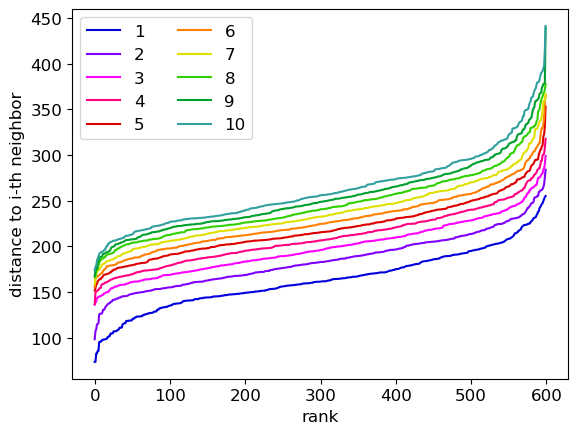

mean minimum distance between nn points:  163.65491354345073


In [66]:
nn = 10
# compute the distance to the nn nearest neighbors
nbrs = NearestNeighbors(n_neighbors=nn+1).fit(X) #, algorithm='ball_tree'
# distances and the indices of the nn nearest neighbors (10+1)
d, ind = nbrs.kneighbors(X) # returns distances and indices of nn neighbors
print(d[3,:],range(ind.max()))
dd=d.T # distances to the i-th neighbor for all points, sorted by distance
print(dd.shape)
# note: dd[0] has a trivial set of zeros
listc= ["#0000DD","#8000FF","#FF00FF","#FF0080","#DD0000",
        "#FF8000","#E0E000","#30D000","#00A030","#33A0A0"]
for i in range(1,nn+1):
    plt.plot(np.sort(dd[i]),c=listc[i-1],label=str(i))
    plt.xlabel("rank")
    plt.ylabel("distance to i-th neighbor")
plt.legend(ncol=2)
plt.show()
mean_min_dist = np.mean(dd[1]) # mean distance to the nearest neighbor
print("mean minimum distance between nn points: ",mean_min_dist)

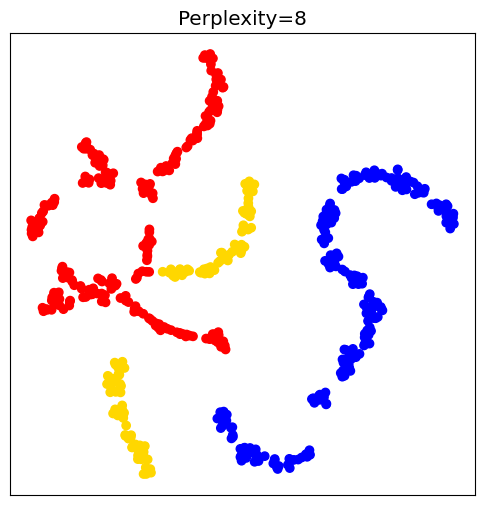

In [67]:
n_samples = N
n_components = 2 
mycmap = ListedColormap(["blue","red","gold" ])

(fig, ax) = plt.subplots(figsize=(6,6))

X_all = [None]

perplexity= 8

np.random.seed(1) #we use 1 as seed for the random state (in the lab's notebook this was considered the best reconstructed data)

t0 = time()
tsne = manifold.TSNE(n_components=n_components, 
                         init='random',random_state=1, 
                         perplexity=perplexity)
Y = tsne.fit_transform(data)
t1 = time()
ax.set_title("Perplexity=%d" % perplexity)
ax.scatter(Y[:, 0], Y[:, 1], c=y_true,cmap=mycmap)
ax.tick_params(left=False,bottom=False)
ax.xaxis.set_major_formatter(NullFormatter())
ax.yaxis.set_major_formatter(NullFormatter())
ax.axis('tight')
X_all.append(Y) # store the t-SNE embedding for later use
    
plt.show()


In [68]:
def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

def entropy(c, n_sample):
    # Measures the shannon entropy of a cluster
    # c is a dictinary of cluster labels to data indices 
    # n_sample is the total number of data points
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

# Normalized mutual information function
# Note that this deals with the label permutation problem
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments
    """
    w = clustering(y_true) # clustering of the true labels
    c = clustering(y_pred) # clustering of the predicted labels
    n_sample = len(y_true)

    Iwc = 0. # mutual information between w and c
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc]))) # number of data points in the intersection of cluster kw and kc
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc]))) # mutual information contribution of the intersection of cluster kw and kc
    Iwc/=n_sample
    Hc = entropy(c,n_sample) # entropy of the predicted clustering
    Hw = entropy(w,n_sample) # entropy of the true clustering

    return 2*Iwc/(Hc+Hw)

def plotting_ax(X, y, ax):
    # plotting function modificata
    for i, yu in enumerate(np.unique(y)):
        pos = (y == yu)
        
        # Conditional statement to highlight outliers (label -1)
        if yu == -1:
            # Exclusive color for outliers
            ax.scatter(X[pos,0], X[pos,1], c='lightgray', s=ms, alpha=0.6, label='Outliers')
            # Creates the legend only if there are outliers
            ax.legend(loc='upper right', fontsize='small')
        else:
            ax.scatter(X[pos,0], X[pos,1], c=cpalette[i % len(cpalette)], s=ms)

## 1. Corrrelations between $\epsilon$ and $m_p$

Best NMI = 0.761 


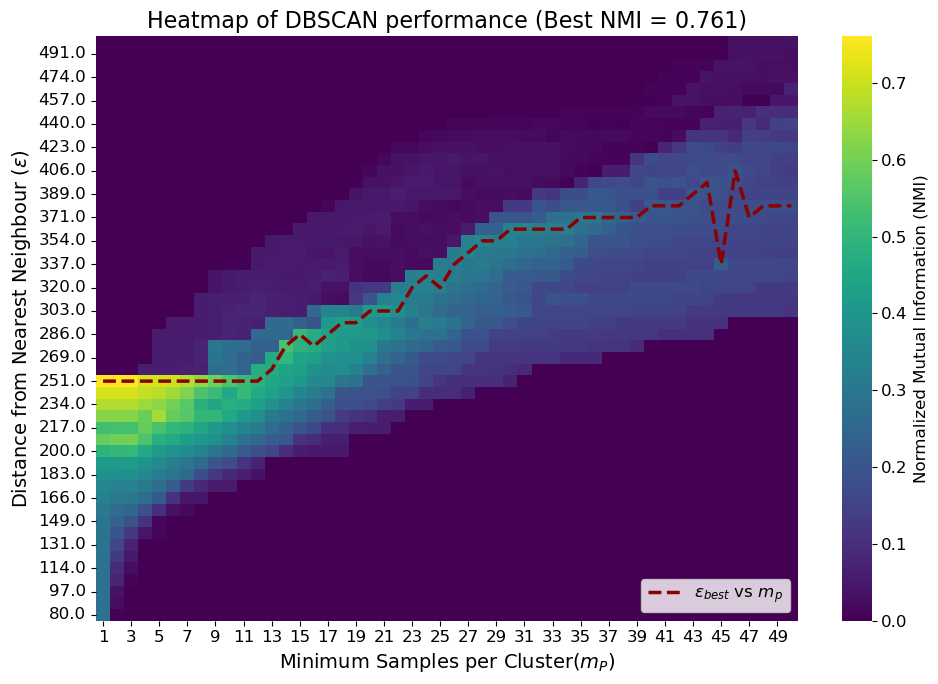

In [69]:
# DBSCAN has a few parameters, let's sweep over a few parameters and see what happens
np.random.seed(12345)

eps_range = np.round(np.linspace(80, 500, 50))
min_sample_range = np.int64(np.linspace(1, 50, 50))

DIMY=len(eps_range) 
DIMX=len(min_sample_range)

nmi = np.zeros((50,50))

for i, eps in enumerate(eps_range):
    for j, min_samples in enumerate(min_sample_range):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        model.fit(X)
        y_hat = model.labels_ # predicted labels
        nmi[i,j]=NMI(y_hat, y_true)

# np.argmax() works on flatten matrix so we get just one index
flat_index = np.argmax(nmi)

# we then convert it into two index corresponding to row and column
best_row, best_col = np.unravel_index(flat_index, nmi.shape)

# get the actual best value on nmi
best_nmi_value = nmi[best_row, best_col]

print(f'Best NMI = {best_nmi_value:.3f} ')



#dataframe for the heatmap
df_nmi = pd.DataFrame(nmi, index=eps_range, columns=min_sample_range)
plt.figure(figsize=(10, 7))

ax = sns.heatmap(df_nmi, cmap="viridis", cbar_kws={'label': 'Normalized Mutual Information (NMI)'})

# finds the index of the best epsilon (row) for every m_p value (column)
best_eps_indices = np.argmax(nmi, axis=0)

# +0.5 because seaborn centers every little cell at half a unit
x_coords = np.arange(len(min_sample_range)) + 0.5
y_coords = best_eps_indices + 0.5

# trendline
ax.plot(x_coords, y_coords, color='darkred', linestyle='--', linewidth=2.5, alpha=1, label='$\epsilon_{best}$ vs $m_p$')

plt.legend(loc='lower right', fontsize=12)

#this puts the lower values of epsilon to the bottom of the y-axis and the higher ones to the top
ax.invert_yaxis()
plt.title(f"Heatmap of DBSCAN performance (Best NMI = {best_nmi_value:.3f})", fontsize=16)
plt.xlabel("Minimum Samples per Cluster($m_P$)", fontsize=14)
plt.ylabel("Distance from Nearest Neighbour ($\epsilon$)", fontsize=14)


plt.tight_layout()
plt.show()

Based on the results of the two cells above, we can say that there's definitely a correlation between $\epsilon$ and $m_p$. This was an expected result: building a cluster with a higher minimum of points inside necessitates larger value of $\epsilon$ to encompass them, while building a cluster with fewer points requires smaller values of $\epsilon$.

In the heatmap this is highlighted by the fact that the "hot" (high NMI) areas move diagonally. The dashed trendline we added further emphasizes this, revealing a linear upward trend.

Furthermore, there is a connection between the best value of $\epsilon$ for a given $m_p$ and the ranked distance plot. Specifically, for any $m_p=k$, the best value of the radius corresponds to the distance at the **elbow** of the $k$-th curve of the plot. For example, for $m_p=3$ we can extract the radius' value from the third curve in the plot of ranked distances around its elbow at the end, finding a value $\epsilon_{best} \approx 250$. The search for these two values on the heatmap gives an almost exact correspondance to the best value $ NMI_{best}=0.761$ totalized with the DBSCAN clustering.

The main idea is that values greater than $\epsilon_{best}$ could lead to the identification of outliers as cluster points, or worse, merge two different clusters together.

## 2. PCA on the noisy 12-Dimensional data

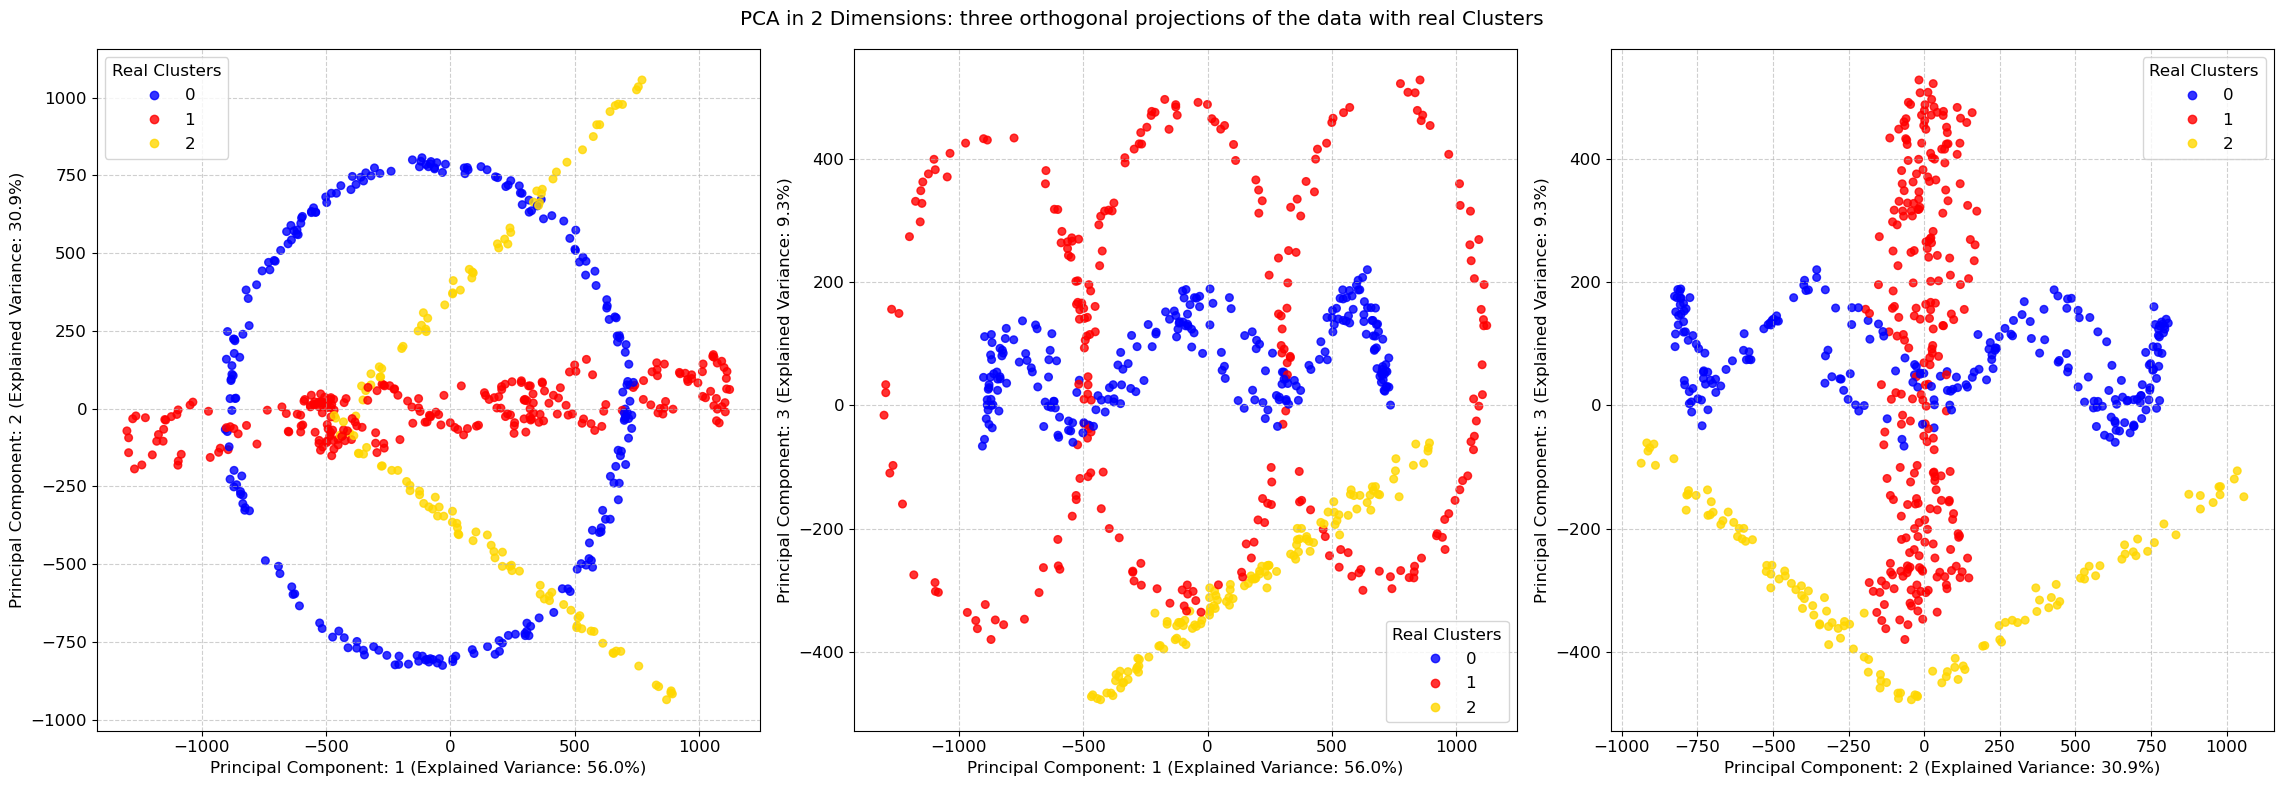

In [70]:
# principal component analysis reducing the data in only two dimensions
pca = PCA(n_components=3)

# applying the pca to the original data X. We obtain a matrix with two columns, one for each dimension
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(23,8))
pairs = [(0,1), (0,2), (1, 2)]

for i in range(3):
    ax = axes[i]

    c1, c2 = pairs[i]
    scatter = ax.scatter(X_pca[:, c1], X_pca[:, c2], c=y_true, cmap=mycmap, s=30, alpha=0.8)

    # this evaluates how descriptive the two components are
    var_1 = pca.explained_variance_ratio_[c1] * 100
    var_2 = pca.explained_variance_ratio_[c2] * 100


    ax.set_xlabel(f"Principal Component: {c1 + 1} (Explained Variance: {var_1:.1f}%)", fontsize=12)
    ax.set_ylabel(f"Principal Component: {c2 +1} (Explained Variance: {var_2:.1f}%)", fontsize=12)

    ax.legend(*scatter.legend_elements(), title="Real Clusters", loc='best')
    ax.grid(True, linestyle='--', alpha=0.6)

fig.suptitle('PCA in 2 Dimensions: three orthogonal projections of the data with real Clusters')
plt.tight_layout()
plt.show()

We performed the PCA on the noisy data to reduce its dimensionality by extracting the three principal components. In the figure we can see three subplots, each corresponding to the projection of the data onto the plane defined by a pair of principal components. This visualization allows us to inspect the original structure of the data from different orthogonal angles. 

We can find a key difference by comparing it with the t-SNE visualization: t-SNE being a non linear technique, separates the data into almost linearly separable groups; on the other hand PCA reveals that the original structure of the data is far more complex and surely not linearly separable.

In general we can say that by inspecting every projection obtained through PCA helps us understand the original structure of the data, compared to the t-SNE results, which reveals and separates the clusters at the expense of the describing the data's original structure.

## K-Means Clustering and comparison with DBSCAN

c:\Users\ricca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


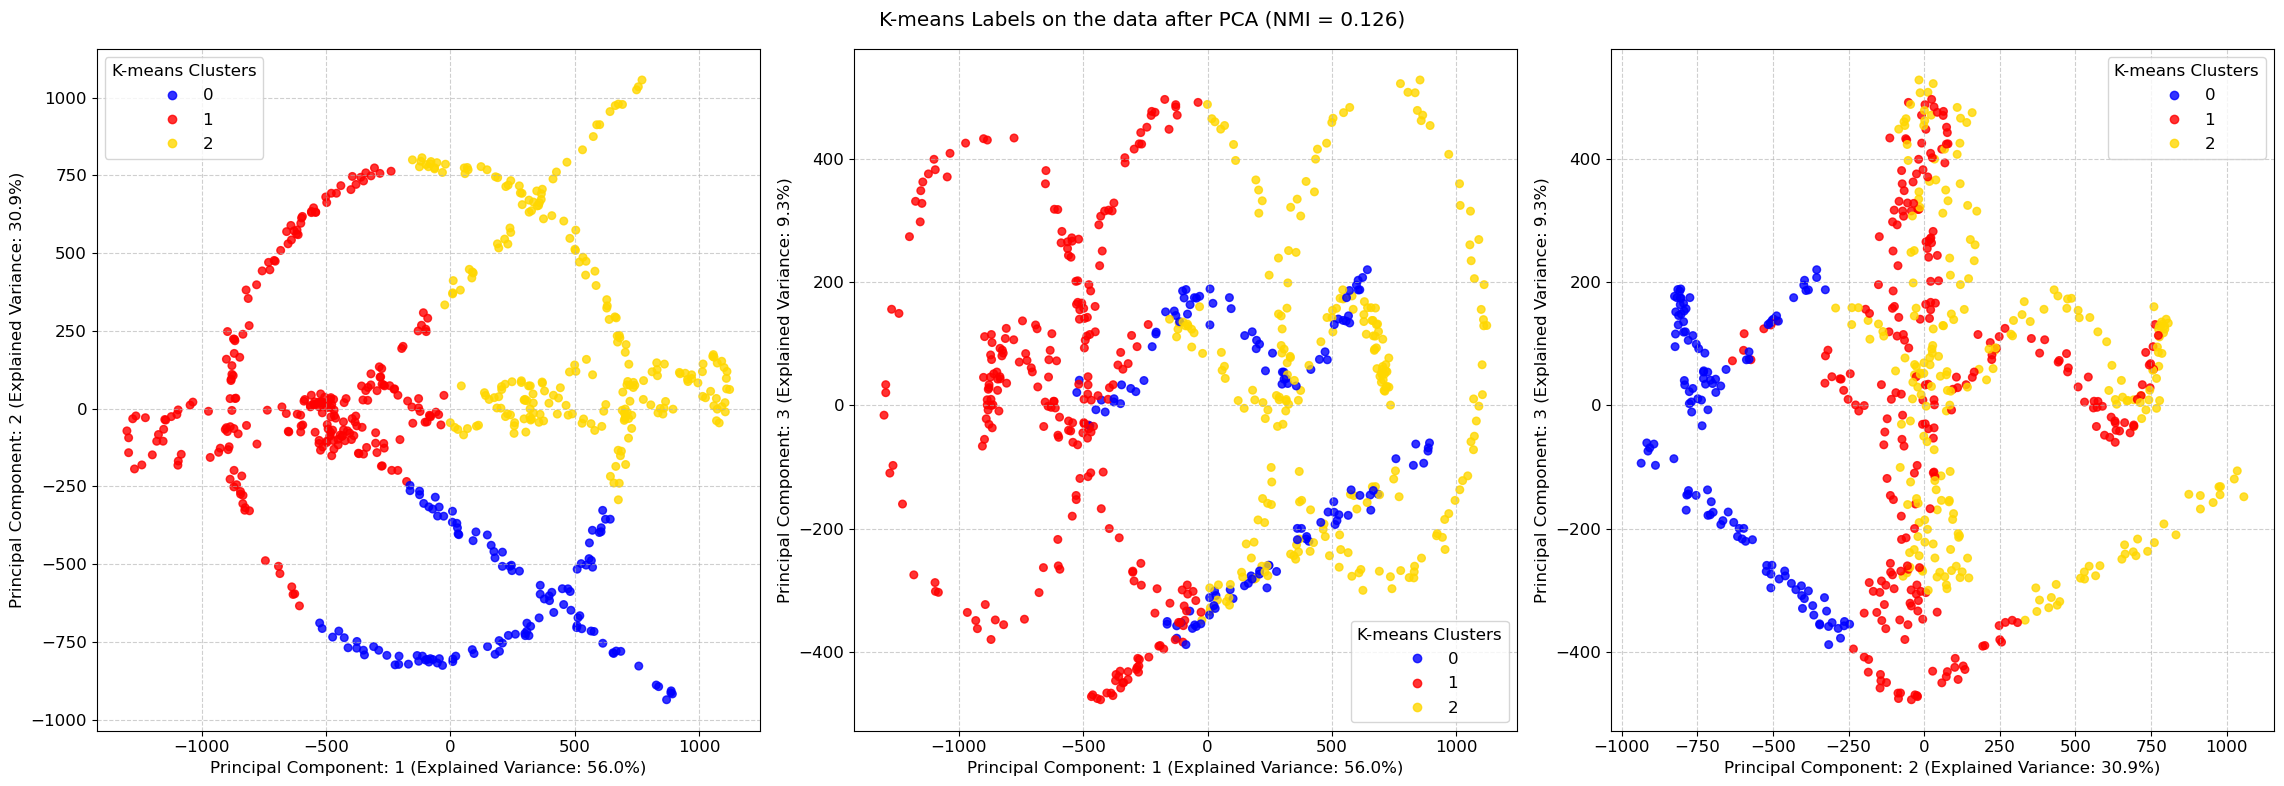

In [71]:
# k-means funcition
kmeans = KMeans(n_clusters=3, random_state=12345, n_init=10)    #we set the same seed used with the DBSCAN 

y_kmeans = kmeans.fit_predict(X)

# NMI for the k-means
nmi_kmeans = NMI(y_true, y_kmeans)

fig, kaxes = plt.subplots(1, 3, figsize=(23, 8))
kpairs = [(0,1), (0,2), (1, 2)]

for i in range(3):
    ax = kaxes[i]

    c1, c2 = kpairs[i]
    scatter = ax.scatter(X_pca[:, c1], X_pca[:, c2], c=y_kmeans, cmap=mycmap, s=30, alpha=0.8)

    # again we print on the axis the explained variance
    var_1 = pca.explained_variance_ratio_[c1] * 100
    var_2 = pca.explained_variance_ratio_[c2] * 100


    ax.set_xlabel(f"Principal Component: {c1 + 1} (Explained Variance: {var_1:.1f}%)", fontsize=12)
    ax.set_ylabel(f"Principal Component: {c2 +1} (Explained Variance: {var_2:.1f}%)", fontsize=12)

    ax.legend(*scatter.legend_elements(), title="K-means Clusters", loc='best')
    ax.grid(True, linestyle='--', alpha=0.6)

fig.suptitle(f'K-means Labels on the data after PCA (NMI = {nmi_kmeans:.3f})')
plt.tight_layout()
plt.show()


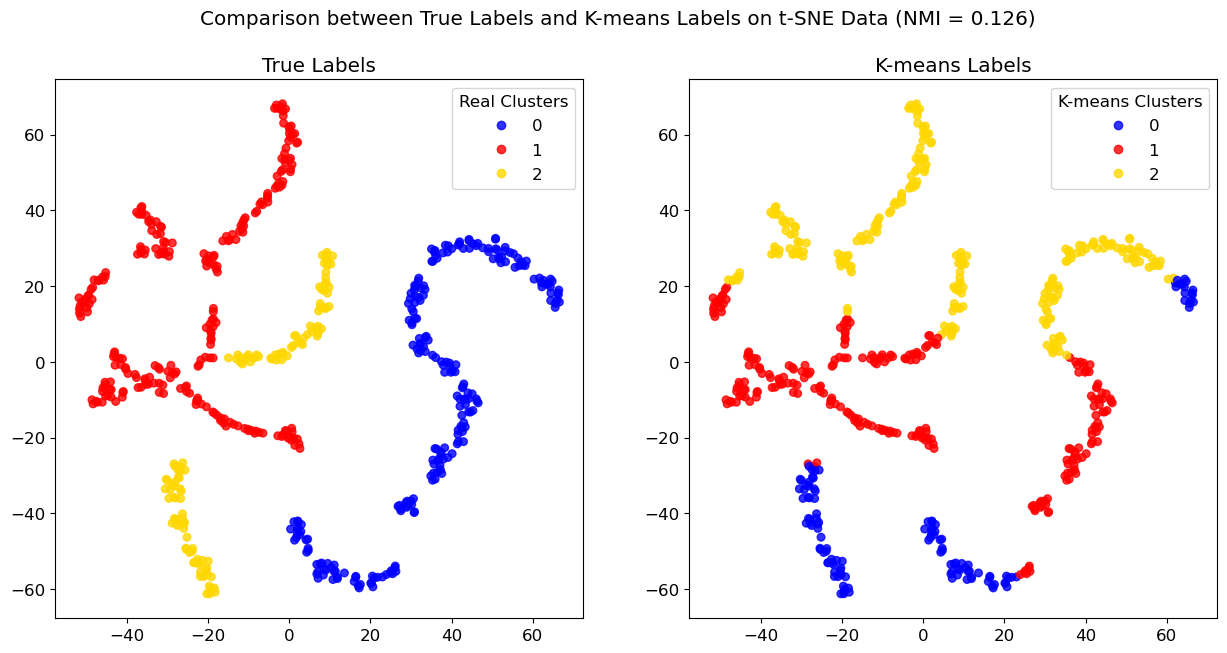

In [72]:
ktsne = X_all[1]
fig, ax = plt.subplots(1, 2, figsize=(15,7))
labels = [y_true, y_kmeans]
title = ['True Labels', 'K-means Labels']
clust = ['Real Clusters', 'K-means Clusters']
for i in range(2):
    plot = ax[i]
    scatter = plot.scatter(ktsne[:,0], ktsne[:,1], c=labels[i], cmap=mycmap, s=30, alpha=0.8)
    plot.set_title(f'{title[i]}')
    plot.legend(*scatter.legend_elements(), title=f'{clust[i]}', loc='best')

plt.suptitle(f'Comparison between True Labels and K-means Labels on t-SNE Data (NMI = {nmi_kmeans:.3})')
plt.show()

Performing the K-means clustering on the data instead of the DBSCAN, does not have any advantages. The calculated NMI between the true labels and the ones found through the K-means is $NMI_{K-means} = 0.126$. 

This difference in performance between the DBSCAN with best parameters and the K-means method was expected since the data are not linearly separable. We know that the K-means algorithm works better on linearly separable datasets, or in general works with the assumption that the data are divided in convex clusters and the ones used in this exercise were clearly not, giving the advantage to the DBSCAN.

The use of one method over the other is then strictly subject to the dataset and its structure.

By showing the data labled with the results of the K-means, both onto the PCA and the t-SNE data, it is clear that although the t-SNE visualization could lead to perceive the data as clustered in distinct groups, that's not how the data really is structured. The PCA visualization on the other hand, is more truthful to the real structure of the data and just by looking at it, it was clear the K-means was going to perform poorly w.r.t DBSCAN.